Thực hành các phép lọc:
a. Đọc ảnh xám, thực hành lọc trung bình, lọc trung bình theo k giá trị gần nhất, lọc trung vị với các W(3x3), W(7x7), W(11x11) và ngưỡng 5, 10, 20, k 3 7 11
b. Thực hiện cuộn với nhân cuộn được tính theo hàm phân phối chuẩn 2 chiều. lựa chọn 3 trường hợp tham số khác nhau
c. Chọn 1 file video giao thông, thực hiện tính chuyển động:
Input: video, ngưỡng T, số n, lựa chọn trung bình hoặc trung vị
Output: video mới
Thực hiện:
Mở video
lặp
  - Đọc frame hiện tại Ic
  - Tính ảnh trung bình (hoặc trung vị) B
    với mọi x, y: B(x, y)  = trung bình (hoặc trung vị) các điểm ảnh (x, y) của n khung hình đến hiện tại
  - phân ngưỡng |Ic - B| với T

a. Đọc ảnh xám, thực hành lọc trung bình, lọc trung bình theo k giá trị gần nhất, lọc trung vị với các W(3x3), W(7x7), W(11x11) và ngưỡng 5, 10, 20, k 3 7 11

In [64]:
import numpy as np 
import cv2 as cv
import matplotlib.pyplot as plt 
import math 

path = "ava1.jpeg"

Height: 414
Width: 736


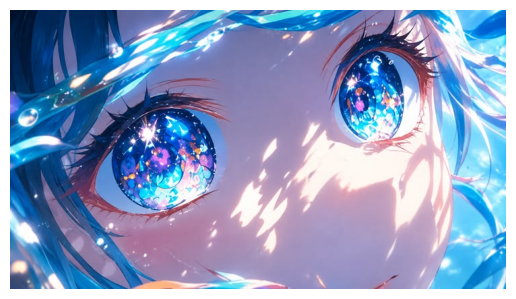

In [65]:
img_original = cv.imread(path)

h, w = img_original.shape[:2]
print("Height:", h)
print("Width:", w)

img_original = cv.cvtColor(img_original, cv.COLOR_BGR2RGB)

plt.imshow(img_original)
plt.axis("off")
plt.show()

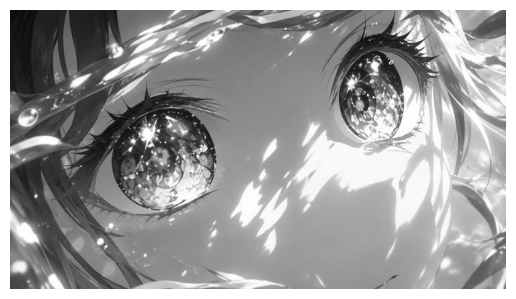

In [66]:
img_gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
plt.imshow(img_gray, cmap = "gray")
plt.axis("off")
plt.show()

In [67]:
def trung_binh(x0, y0, I, W):
    h, w = W[0], W[1]
    dy, dx = h // 2, w // 2
    x, y = x0 - dx, y0 - dy

    total = 0.0

    for i in range(y, y + h):
        for j in range(x, x + w):
            total += int(I[i, j])

    return round(total / (w * h))


def loc_trung_binh(I, W=(3, 3), theta=1):
    wh, ww = W[0], W[1]
    dy, dx = wh // 2, ww // 2

    I_kq = np.copy(I)

    for y in range(dy, I.shape[0] - dy):
        for x in range(dx, I.shape[1] - dx):

            avp = trung_binh(x, y, I, W)

            if abs(int(I[y, x]) - int(avp)) > theta:
                I_kq[y, x] = avp

    return I_kq

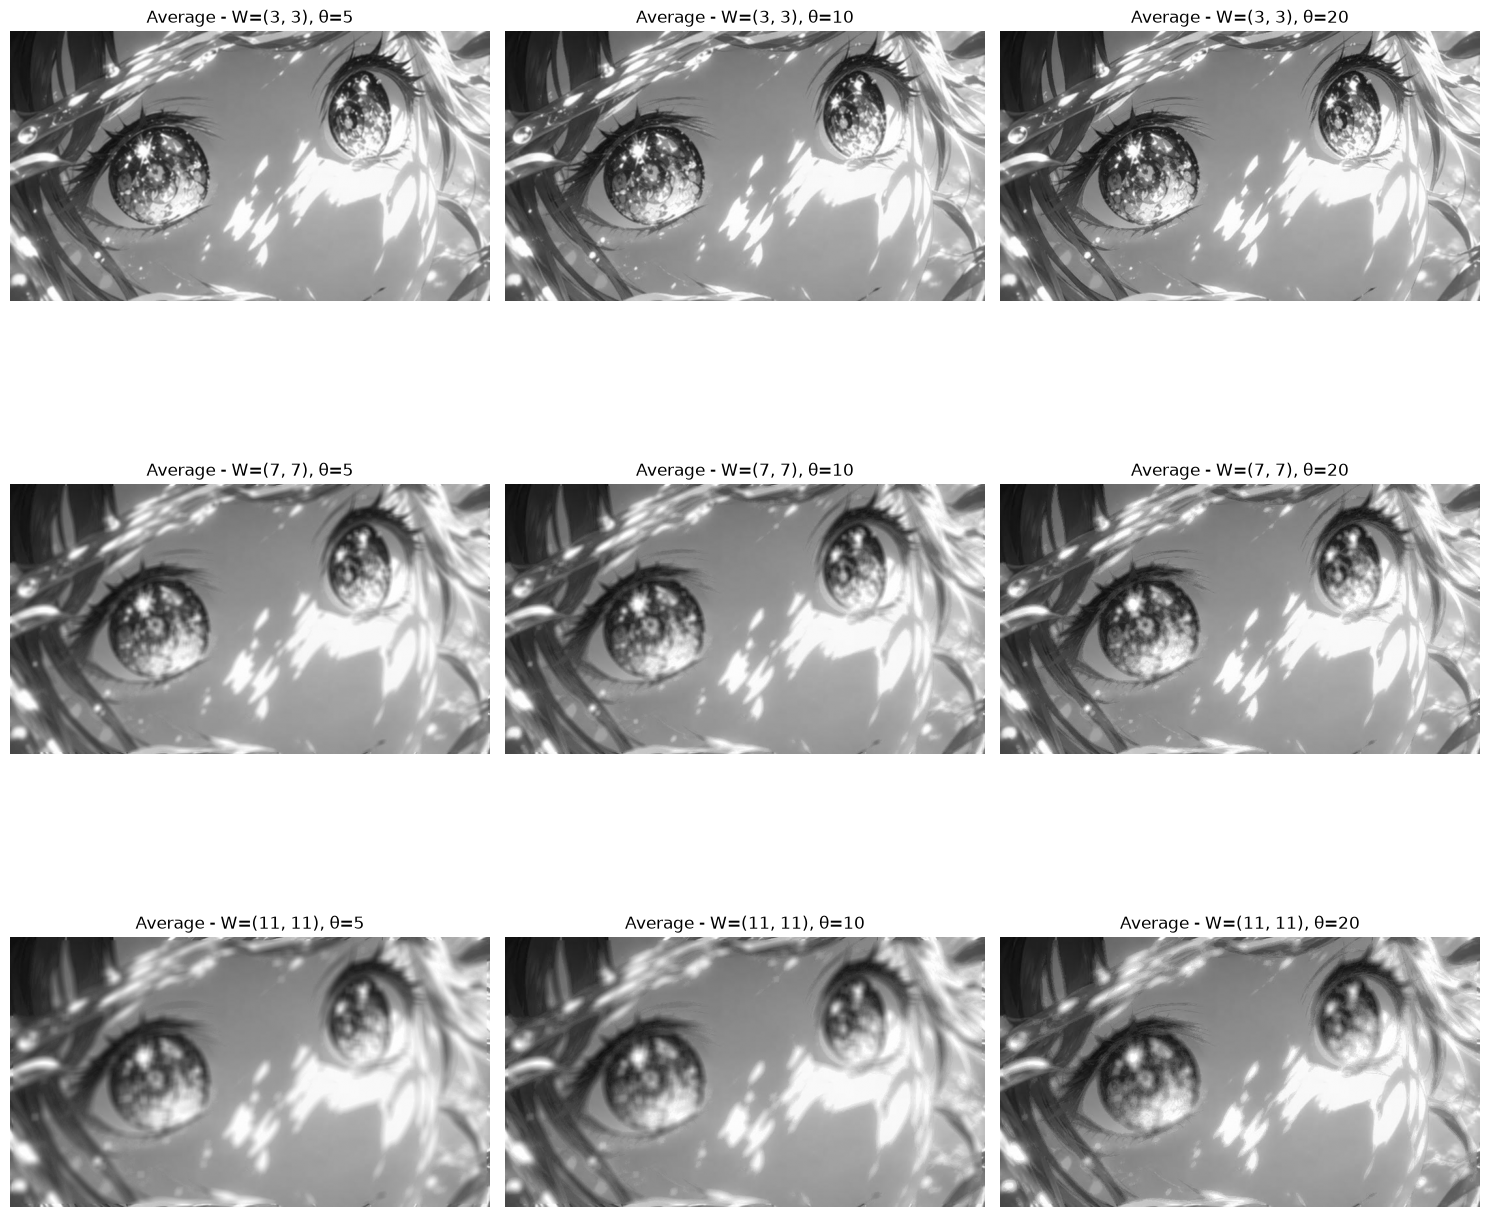

In [81]:
Ws = [(3, 3), (7, 7), (11, 11)]
thetas = [5, 10, 20]

plt.figure(figsize=(15, 15))
i = 1
for W in Ws:
    for theta in thetas:
        kq = loc_trung_binh(img_gray, W=W, theta=theta)
        plt.subplot(3, 3, i)
        plt.imshow(kq, cmap="gray", vmin=0, vmax=255)
        plt.title(f"Average - W={W}, θ={theta}")
        plt.axis("off")
        i += 1
plt.tight_layout()
plt.show()

In [69]:
# loc avg theo k gia tri gan nhat 

def trung_binh_k_gan_nhat(x0, y0, I, W, k):
    h, w = W[0], W[1]
    dy, dx = h // 2, w // 2

    x, y = x0 - dx, y0 - dy

    center = int(I[y0, x0])

    values = []

    for i in range(y, y + h):
        for j in range(x, x + w):
            value = int(I[i, j])
            distance = abs(value - center)

            values.append((distance, value))

    # Sắp xếp theo khoảng cách tăng dần
    values.sort(key=lambda x: x[0])

    # Lấy k giá trị gần nhất
    k_values = [value for distance, value in values[:k]]

    return round(sum(k_values) / k)

def loc_trung_binh_k_gan_nhat(I, W=(3, 3), k=3, theta=1):
    wh, ww = W[0], W[1]
    dy, dx = wh // 2, ww // 2

    I_kq = np.copy(I)

    for y in range(dy, I.shape[0] - dy):
        for x in range(dx, I.shape[1] - dx):

            avp = trung_binh_k_gan_nhat(x, y, I, W, k)

            if abs(int(I[y, x]) - int(avp)) > theta:
                I_kq[y, x] = avp

    return I_kq

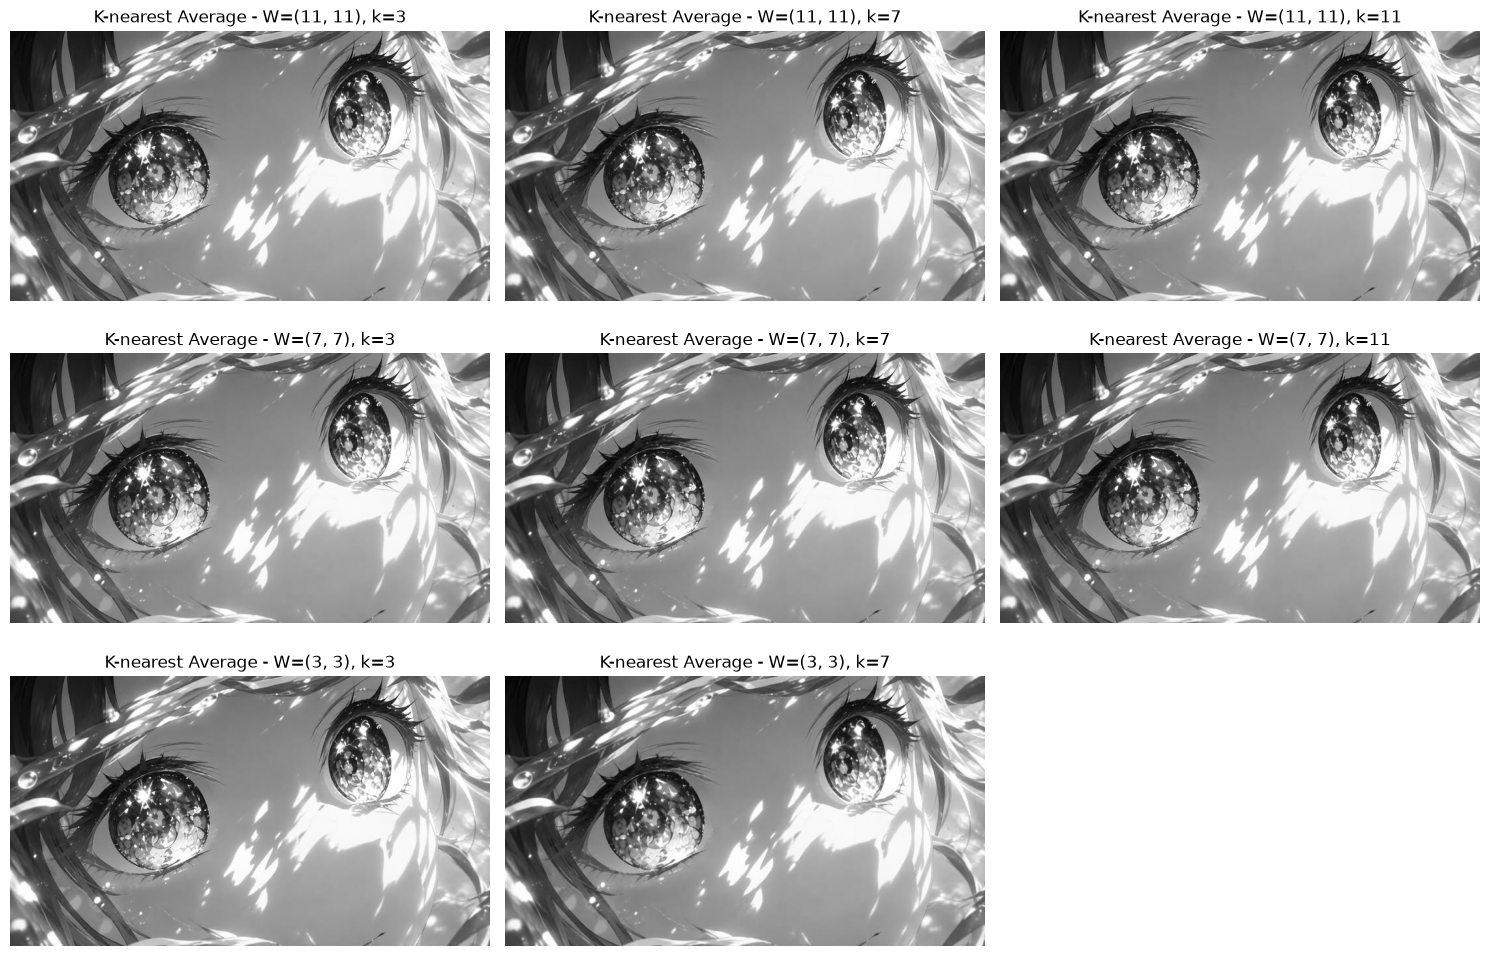

In [79]:
results_k = []
params_k = []

for W in [(11, 11), (7, 7), (3, 3)]:
    for k in [3, 7, 11]:

        if k <= W[0] * W[1]:
            results_k.append(
                loc_trung_binh_k_gan_nhat(
                    img_gray,
                    W=W,
                    k=k,
                    theta=5
                )
            )

            params_k.append((W, k))

plt.figure(figsize=(15, 10))

for i, (img, (W, k)) in enumerate(
    zip(results_k, params_k),
    1
):
    plt.subplot(3, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(f"K-nearest Average - W={W}, k={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [76]:
def trung_vi(x0, y0, I, W):
    h, w = W[0], W[1]
    dy, dx = h // 2, w // 2

    x, y = x0 - dx, y0 - dy

    values = []

    for i in range(y, y + h):
        for j in range(x, x + w):
            values.append(int(I[i, j]))

    values.sort()

    return values[len(values) // 2]

def loc_trung_vi(I, W=(3, 3), theta=1):
    wh, ww = W[0], W[1]
    dy, dx = wh // 2, ww // 2

    I_kq = np.copy(I)

    for y in range(dy, I.shape[0] - dy):
        for x in range(dx, I.shape[1] - dx):

            med = trung_vi(x, y, I, W)

            if abs(int(I[y, x]) - int(med)) > theta:
                I_kq[y, x] = med

    return I_kq

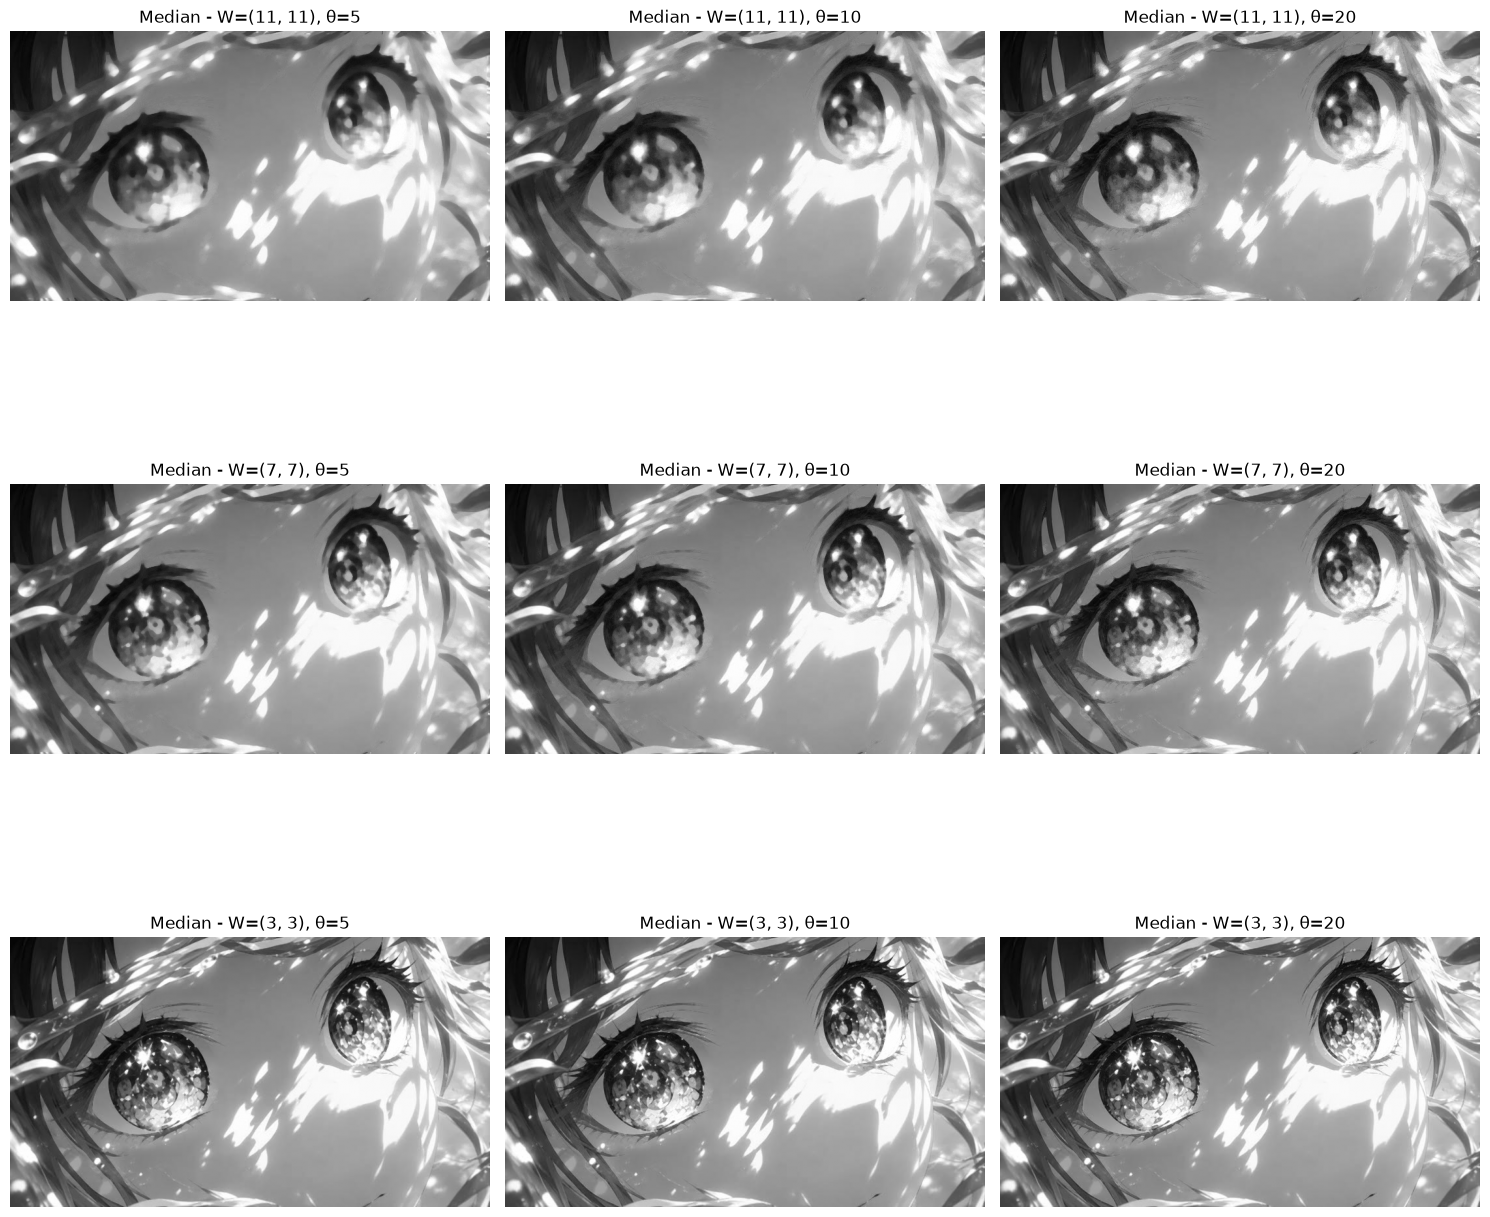

In [80]:
results_median = []

for W in [(11, 11), (7, 7), (3, 3)]:
    for theta in [5, 10, 20]:

        results_median.append(
            loc_trung_vi(
                img_gray,
                W=W,
                theta=theta
            )
        )

plt.figure(figsize=(15, 15))

i = 1

for W in [(11, 11), (7, 7), (3, 3)]:
    for theta in [5, 10, 20]:

        plt.subplot(3, 3, i)
        plt.imshow(results_median[i - 1], cmap="gray")
        plt.title(f"Median - W={W}, θ={theta}")
        plt.axis("off")

        i += 1

plt.tight_layout()
plt.show()

b. Thực hiện cuộn với nhân cuộn được tính theo hàm phân phối chuẩn 2 chiều. lựa chọn 3 trường hợp tham số khác nhau

In [ ]:
def gaussian_kernel(size, sigma):
    k = size // 2

    x, y = np.meshgrid(
        np.arange(-k, k + 1),
        np.arange(-k, k + 1)
    )

    kernel = np.exp(
        -(x**2 + y**2) / (2 * sigma**2)
    )

    kernel = kernel / np.sum(kernel)

    return kernel

def gaussian_filter(I, size, sigma):
    kernel = gaussian_kernel(size, sigma)

    return cv.filter2D(
        I,
        -1,
        kernel
    )

In [ ]:
params = [
    (3, 0.5),
    (7, 1.5),
    (11, 3.0)
]

In [ ]:
results = []

for size, sigma in params:
    result = gaussian_filter(
        img_gray,
        size,
        sigma
    )

    results.append(result)

In [ ]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

for i, ((size, sigma), img) in enumerate(
    zip(params, results),
    2
):
    plt.subplot(1, 4, i)

    plt.imshow(img, cmap="gray")
    plt.title(f"size={size}, σ={sigma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

c. Chọn 1 file video giao thông, thực hiện tính chuyển động:
Input: video, ngưỡng T, số n, lựa chọn trung bình hoặc trung vị
Output: video mới
Thực hiện:
Mở video
lặp
  - Đọc frame hiện tại Ic
  - Tính ảnh trung bình (hoặc trung vị) B
    với mọi x, y: B(x, y)  = trung bình (hoặc trung vị) các điểm ảnh (x, y) của n khung hình đến hiện tại
  - phân ngưỡng |Ic - B| với T